In [53]:
from __future__ import annotations

import argparse
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [54]:
DEFAULT_INPUT = Path("Data/resale_2021plus_with_amenity_distances.parquet")
DEFAULT_OUTPUT = Path("artifacts/age_cohort_value_scores.csv")



In [55]:
# Cohort weights copied verbatim from ``ml-aat.ipynb``
WEIGHTS_20_29: Dict[str, float] = {
    "distToMrtExit": 4.03,
    "Transacted Price ($)": 5.0,
    "Area (SQM)": 3.0,
    "distToHawker": 3.0,
    "distToGym": 3.0,
}

WEIGHTS_40_49: Dict[str, float] = {
    "distToMrtExit": 2.58,
    "Transacted Price ($)": 3.0,
    "Area (SQM)": 5.0,
    "distToHawker": 5.0,
    "distToGym": 5.0,
}

# Required columns in the source dataset: (source_column, target_name)
CRITERIA_MAP = {
    "dist_m_mrt_exit": "distToMrtExit",
    "resale_price": "Transacted Price ($)",
    "floor_area_sqm": "Area (SQM)",
    "dist_m_hawker": "distToHawker",
    "dist_m_gym": "distToGym",
}

In [56]:
CCR = {
    "DOWNTOWN CORE",
    "ORCHARD",
    "NEWTON",
    "RIVER VALLEY",
    "OUTRAM",
    "ROCHOR",
    "MUSEUM",
    "MARINA SOUTH",
    "MARINA EAST",
    "SINGAPORE RIVER",
    "SOUTHERN ISLANDS",
    "BUKIT TIMAH",
}

RCR = {
    "KALLANG",
    "WHAMPOA",
    "NOVENA",
    "TOA PAYOH",
    "GEYLANG",
    "BUKIT MERAH",
    "MARINE PARADE",
    "QUEENSTOWN",
}

REGION_ORDER = ("CCR", "RCR", "OCR")

def to_region(value: str | float | None) -> str:
    """Map a planning area/town label to CCR/RCR/OCR buckets."""

    if value is None or pd.isna(value):
        return "OCR"
    u = str(value).strip().upper()
    if not u:
        return "OCR"

    if u in CCR:
        return "CCR"
    if u in RCR:
        return "RCR"
    return "OCR"


In [57]:
def load_resale_data(path: Path) -> pd.DataFrame:
    """Load the resale dataset that already contains towns."""

    if not path.exists():
        raise FileNotFoundError(f"Input dataset not found at {path}")

    if path.suffix.lower() == ".csv":
        df = pd.read_csv(path)
    else:
        df = pd.read_parquet(path)

    needed = set(CRITERIA_MAP.keys()) | {"town"}
    missing = needed - set(df.columns)
    if missing:
        raise KeyError(f"Missing required columns: {sorted(missing)}")

    df = df.copy()
    for col in CRITERIA_MAP.keys():
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df["town"] = df["town"].astype(str).str.strip()
    df = df.dropna(subset=["town"])
    return df



In [58]:
def aggregate_by_town(df: pd.DataFrame) -> pd.DataFrame:
    """Replicate the town-level aggregation used in the friend's notebook."""

    agg_dict = {
        source: (source, "median") for source in CRITERIA_MAP.keys()
    }
    agg_dict["Count"] = ("town", "size")

    grouped = (
        df.groupby("town", observed=True)
        .agg(**agg_dict)
        .reset_index()
    )

    grouped = grouped.rename(columns={source: target for source, target in CRITERIA_MAP.items()})
    grouped["Town"] = grouped["town"].astype(str).str.strip()
    grouped = grouped.drop(columns=["town"])

    # Reorder to keep the presentation close to the source notebook
    ordered_cols = [
        "Town",
        "distToMrtExit",
        "Transacted Price ($)",
        "Area (SQM)",
        "distToHawker",
        "distToGym",
        "Count",
    ]
    return grouped[ordered_cols]



In [59]:
def calculate_normalized_scores(df: pd.DataFrame, column: str, lower_is_better: bool) -> Dict[str, float]:
    """Apply the same rank-based normalisation as the reference notebook."""

    total = len(df)
    if total == 0:
        return {}

    sorted_df = (
        df[["Town", column]]
        .copy()
        .sort_values(column, ascending=lower_is_better)
        .reset_index(drop=True)
    )
    sorted_df["rank"] = sorted_df.index
    denom = max(total - 1, 1)
    sorted_df["normalized_score"] = (total - sorted_df["rank"] - 1) / denom
    return dict(zip(sorted_df["Town"], sorted_df["normalized_score"].astype(float)))



In [60]:
def compute_value_scores(town_df: pd.DataFrame) -> pd.DataFrame:
    """Generate value scores for the 20-29 and 40-49 cohorts."""

    if town_df.empty:
        raise ValueError("No towns available for scoring.")

    criteria_cols = [
        "distToMrtExit",
        "Transacted Price ($)",
        "Area (SQM)",
        "distToHawker",
        "distToGym",
    ]
    subset = town_df.dropna(subset=criteria_cols).reset_index(drop=True)
    total_towns = len(subset)
    if total_towns == 0:
        raise ValueError("Insufficient complete towns for scoring.")

    score_df = subset[["Town"]].copy()
    for column in criteria_cols:
        lower_is_better = column != "Area (SQM)"
        mapping = calculate_normalized_scores(subset, column, lower_is_better=lower_is_better)
        score_df[f"score_{column}"] = score_df["Town"].map(mapping).astype(float)

    def _weighted_score(row: pd.Series, weights: Dict[str, float]) -> float:
        total_weight = sum(weights.values())
        if total_weight == 0:
            return float("nan")
        accum = 0.0
        for key, weight in weights.items():
            accum += row[f"score_{key}"] * weight
        return accum / total_weight * 100.0

    score_df["Value_Score_20_29"] = score_df.apply(_weighted_score, axis=1, weights=WEIGHTS_20_29)
    score_df["Value_Score_40_49"] = score_df.apply(_weighted_score, axis=1, weights=WEIGHTS_40_49)

    final = score_df.merge(
        subset[["Town", *criteria_cols, "Count"]],
        on="Town",
        how="left",
    )
    final["Region"] = final["Town"].apply(to_region)
    return final.sort_values("Value_Score_20_29", ascending=False).reset_index(drop=True)



In [61]:
def format_top_bottom(df: pd.DataFrame, column: str, n: int = 5) -> str:
    """Return a string with the top/bottom blocks for quick CLI feedback."""

    top = df.nlargest(n, column)[["Town", column]].round(3)
    bottom = df.nsmallest(n, column)[["Town", column]].round(3)
    lines = [
        f"VALUE SCORES FOR {column.replace('_', ' ').upper()}",
        "Top towns:",
        top.to_string(index=False),
        "\nBottom towns:",
        bottom.to_string(index=False),
    ]
    return "\n".join(lines)


In [62]:
def summarize_region_scores(df: pd.DataFrame) -> pd.DataFrame:
    """Summarise value scores for CCR/RCR/OCR."""

    summary = (
        df.groupby("Region")
        .agg(
            Towns=("Town", "nunique"),
            Mean_20_29=("Value_Score_20_29", "mean"),
            Median_20_29=("Value_Score_20_29", "median"),
            Mean_40_49=("Value_Score_40_49", "mean"),
            Median_40_49=("Value_Score_40_49", "median"),
        )
    )
    ordered_index = [region for region in REGION_ORDER if region in summary.index]
    return summary.loc[ordered_index].reset_index()


In [63]:

def parse_args(arg_list: list[str] | None = None) -> argparse.Namespace:
    """Parse CLI arguments while tolerating extra Jupyter/IDE flags."""

    parser = argparse.ArgumentParser(description="Compute age-cohort value scores per town.")
    parser.add_argument(
        "--input",
        type=Path,
        default=DEFAULT_INPUT,
        help=f"Path to enriched resale dataset (default: {DEFAULT_INPUT})",
    )
    parser.add_argument(
        "--output",
        type=Path,
        default=DEFAULT_OUTPUT,
        help=f"Where to write the CSV of final scores (default: {DEFAULT_OUTPUT})",
    )
    args, _ = parser.parse_known_args(arg_list)
    return args


In [64]:
args = parse_args()
resale_df = load_resale_data(args.input)
town_df = aggregate_by_town(resale_df)
final_scores = compute_value_scores(town_df)

args.output.parent.mkdir(parents=True, exist_ok=True)
final_scores.to_csv(args.output, index=False)
print(f"Saved cohort value scores → {args.output}")

region_summary = summarize_region_scores(final_scores)
print("\n" + "=" * 80)
print("REGION VALUE SCORE SUMMARY")
print(
    region_summary.to_string(
        index=False,
        formatters={
            "Mean_20_29": "{:.2f}".format,
            "Median_20_29": "{:.2f}".format,
            "Mean_40_49": "{:.2f}".format,
            "Median_40_49": "{:.2f}".format,
        },
    )
)

for col in ("Value_Score_20_29", "Value_Score_40_49"):
    print("\n" + "=" * 80)
    print(format_top_bottom(final_scores, col))


Saved cohort value scores → artifacts/age_cohort_value_scores.csv

REGION VALUE SCORE SUMMARY
Region  Towns Mean_20_29 Median_20_29 Mean_40_49 Median_40_49
   CCR      1      52.91        52.91      64.39        64.39
   RCR      5      52.54        49.16      54.93        52.59
   OCR     20      49.22        47.73      48.05        46.49

VALUE SCORES FOR VALUE SCORE 20 29
Top towns:
         Town  Value_Score_20_29
BUKIT PANJANG             72.268
      GEYLANG             71.374
 CENTRAL AREA             67.146
  JURONG EAST             65.513
   ANG MO KIO             61.715

Bottom towns:
     Town  Value_Score_20_29
PASIR RIS             29.291
SERANGOON             30.440
SEMBAWANG             34.911
  PUNGGOL             38.742
  HOUGANG             39.745

VALUE SCORES FOR VALUE SCORE 40 49
Top towns:
         Town  Value_Score_40_49
BUKIT PANJANG             69.874
      GEYLANG             66.262
 CENTRAL AREA             65.843
  BUKIT TIMAH             64.389
  JURONG EAS

## CCR/RCR/OCR value score summary

Bucket the aggregated towns into CCR/RCR/OCR using the provided planning-area map and summarise the cohort scores.


In [65]:
region_summary = summarize_region_scores(final_scores)
region_summary.style.format(
    {
        "Mean_20_29": "{:.2f}".format,
        "Median_20_29": "{:.2f}".format,
        "Mean_40_49": "{:.2f}".format,
        "Median_40_49": "{:.2f}".format,
    }
)


,Region,Towns,Mean_20_29,Median_20_29,Mean_40_49,Median_40_49
0,CCR,1,52.91,52.91,64.39,64.39
1,RCR,5,52.54,49.16,54.93,52.59
2,OCR,20,49.22,47.73,48.05,46.49


## Visualising cohort value scores

With `final_scores` in memory we can quickly inspect how towns rank for the two age cohorts. The next cells build a few diagnostic plots straight from the computed table.



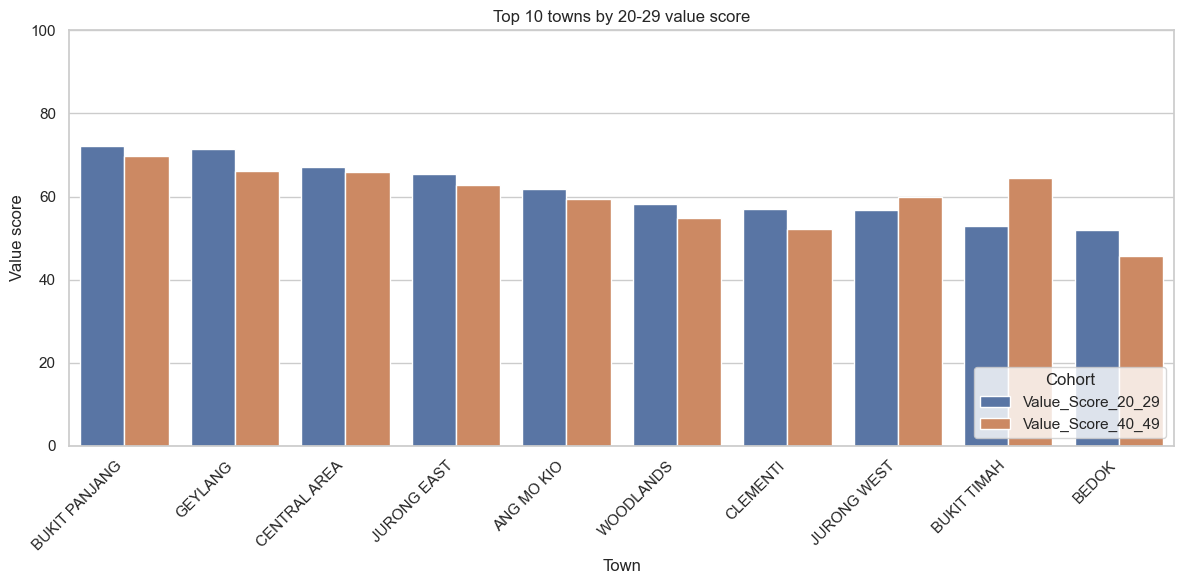

In [66]:
top_n = 10
sns.set_theme(style="whitegrid")
top_towns = (
    final_scores.nlargest(top_n, "Value_Score_20_29")[
        ["Town", "Value_Score_20_29", "Value_Score_40_49"]
    ]
    .melt(id_vars="Town", var_name="Cohort", value_name="Value Score")
)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_towns, x="Town", y="Value Score", hue="Cohort")
plt.ylim(0, 100)
plt.title(f"Top {top_n} towns by 20-29 value score")
plt.xlabel("Town")
plt.ylabel("Value score")
plt.legend(title="Cohort", loc="lower right")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


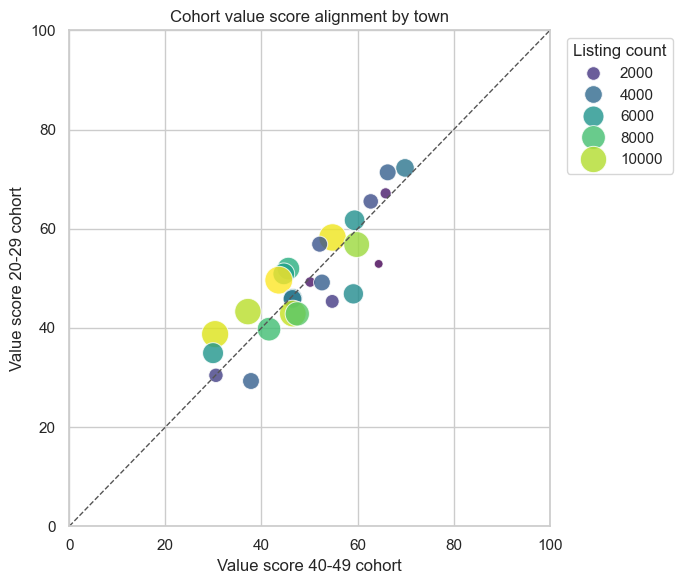

In [67]:
plt.figure(figsize=(7, 6))
scatter = sns.scatterplot(
    data=final_scores,
    x="Value_Score_40_49",
    y="Value_Score_20_29",
    size="Count",
    sizes=(40, 400),
    hue="Count",
    palette="viridis",
    alpha=0.8,
)
plt.plot([0, 100], [0, 100], ls="--", color="#555555", linewidth=1)
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.xlabel("Value score 40-49 cohort")
plt.ylabel("Value score 20-29 cohort")
plt.title("Cohort value score alignment by town")
plt.legend(title="Listing count", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



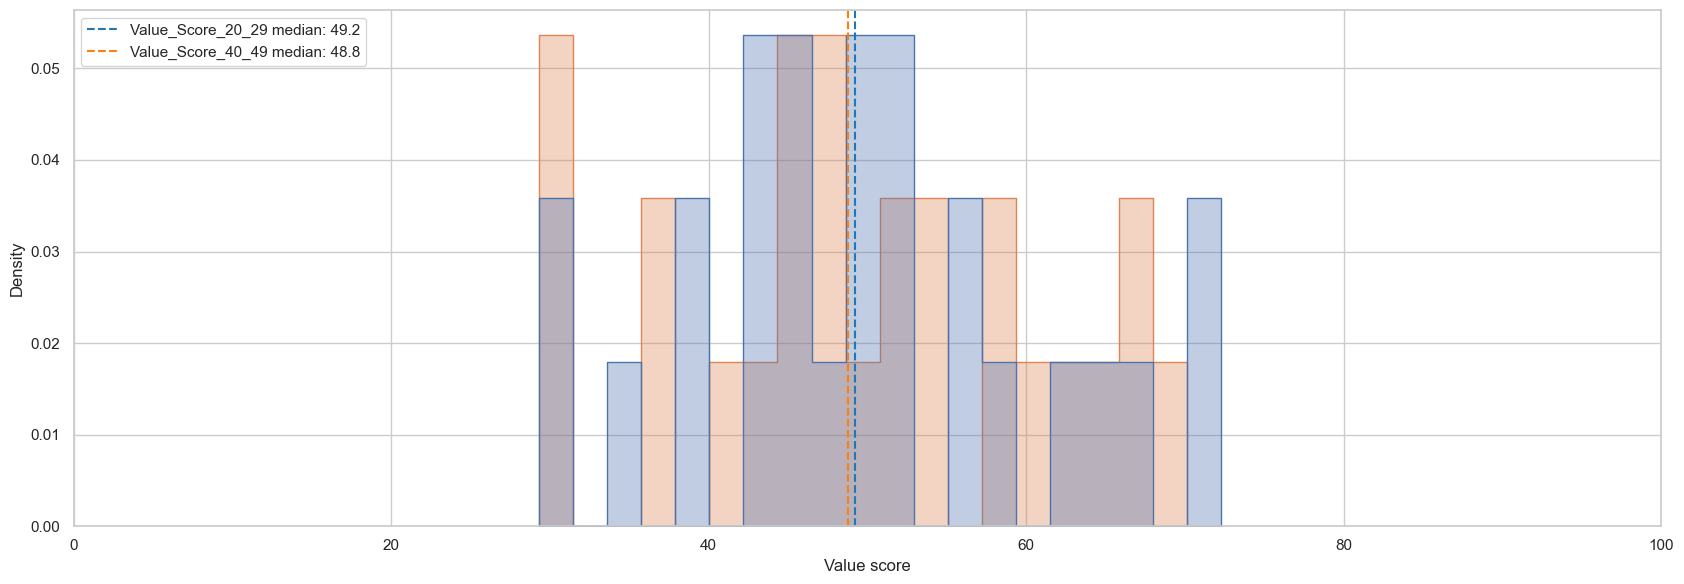

In [73]:
score_distribution = final_scores[["Value_Score_20_29", "Value_Score_40_49"]].melt(
    var_name="Cohort", value_name="Value Score"
)

plt.figure(figsize=(9, 6))
sns.histplot(
    data=score_distribution,
    x="Value Score",
    hue="Cohort",
    bins=20,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.35,
)
for cohort, color in [("Value_Score_20_29", "tab:blue"), ("Value_Score_40_49", "tab:orange")]:
    median_val = final_scores[cohort].median()
    plt.axvline(median_val, color=color, linestyle="--", linewidth=1.5, label=f"{cohort} median: {median_val:.1f}")
plt.xlim(0, 100)
# plt.title("Distribution of value scores across towns")
plt.xlabel("Value score")
plt.ylabel("Density")
plt.legend(loc="upper left")
plt.gcf().set_size_inches(17, 6)
plt.tight_layout()
plt.show()

